In [1]:
!pip install -q decoupler

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.4/147.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.5/230.5 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency

In [2]:
import decoupler as dc
import pandas as pd
import numpy as np

print("Decoupler version:", dc.__version__)

Decoupler version: 2.2.0


In [3]:
import pandas as pd
import numpy as np

# Load files
expression = pd.read_csv("/content/GSE164871_expression_matrix.csv", index_col=0)
metadata = pd.read_csv("/content/GSE164871_metadata.csv")

print("Expression shape:", expression.shape)
print("Metadata shape:", metadata.shape)

print("\nExpression:")
display(expression.head())

print("\nMetadata:")
display(metadata)

FileNotFoundError: [Errno 2] No such file or directory: '/content/GSE164871_expression_matrix.csv'

In [4]:
from google.colab import files

uploaded = files.upload()

Saving differential_expression.csv to differential_expression.csv
Saving GSE164871_metadata (1).csv to GSE164871_metadata (1).csv


In [5]:
import os

print("Files in Colab:")
print(os.listdir("/content"))

Files in Colab:
['.config', 'GSE164871_metadata (1).csv', 'differential_expression.csv', 'sample_data']


In [6]:
import pandas as pd
import numpy as np

expression = pd.read_csv(
    "/content/GSE164871_expression_matrix.csv",
    index_col=0
)

metadata = pd.read_csv(
    "/content/GSE164871_metadata.csv"
)

print("Expression shape:", expression.shape)
print("Metadata shape:", metadata.shape)

display(expression.head())
display(metadata)

FileNotFoundError: [Errno 2] No such file or directory: '/content/GSE164871_expression_matrix.csv'

In [8]:
from google.colab import files

uploaded = files.upload()

Saving GSE164871_expression_matrix.csv to GSE164871_expression_matrix.csv


In [9]:
import pandas as pd
import numpy as np

expression = pd.read_csv(
    "/content/GSE164871_expression_matrix.csv",
    index_col=0
)

metadata = pd.read_csv(
    "/content/GSE164871_metadata.csv"
)

print("Expression shape:", expression.shape)
print("Metadata shape:", metadata.shape)

display(expression.head())
display(metadata)

FileNotFoundError: [Errno 2] No such file or directory: '/content/GSE164871_metadata.csv'

In [10]:
import pandas as pd
import numpy as np

expression = pd.read_csv(
    "/content/GSE164871_expression_matrix.csv",
    index_col=0
)

metadata = pd.read_csv(
    "/content/GSE164871_metadata (1).csv"
)

print("Expression shape:", expression.shape)
print("Metadata shape:", metadata.shape)

display(expression.head())
display(metadata)

Expression shape: (39376, 8)
Metadata shape: (8, 2)


,GSM5021302,GSM5021303,GSM5021304,GSM5021305,GSM5021306,GSM5021307,GSM5021308,GSM5021309
GeneID,,,,,,,,
100287102,4,7,0,4,3,1,1,4
653635,829,848,399,343,1032,405,574,561
102466751,50,62,21,10,61,21,30,24
107985730,1,1,0,0,2,0,0,0
100302278,0,0,1,0,1,0,0,0


,sample,condition
0,GSM5021302,Control
1,GSM5021303,Control
2,GSM5021304,Control
3,GSM5021305,Control
4,GSM5021306,Disease
5,GSM5021307,Disease
6,GSM5021308,Disease
7,GSM5021309,Disease


In [11]:
# Make sure genes are rows and samples are columns
expression = expression.apply(pd.to_numeric, errors="coerce")

# Remove rows without a valid GeneID
expression = expression[expression.index.notna()]

print("Expression shape:", expression.shape)
print("Number of samples:", expression.shape[1])

Expression shape: (39376, 8)
Number of samples: 8


In [12]:
!pip install -q mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 1.2 MB/s eta 0:00:00


In [13]:
import mygene

# Check the columns
print(expression.columns.tolist()[:10])

# Set GeneID as the row index
expression = expression.set_index("GeneID")

# Convert Gene IDs to integers where possible
expression.index = pd.to_numeric(expression.index, errors="coerce")

# Remove invalid Gene IDs
expression = expression[expression.index.notna()]
expression.index = expression.index.astype(int).astype(str)

print("Expression shape:", expression.shape)
print("First Gene IDs:", expression.index[:5].tolist())

['GSM5021302', 'GSM5021303', 'GSM5021304', 'GSM5021305', 'GSM5021306', 'GSM5021307', 'GSM5021308', 'GSM5021309']


KeyError: "None of ['GeneID'] are in the columns"

In [14]:
print("Index name:", expression.index.name)
print("Columns:", expression.columns.tolist())
print("First 5 index values:", expression.index[:5].tolist())
print()
display(expression.head())

Index name: GeneID
Columns: ['GSM5021302', 'GSM5021303', 'GSM5021304', 'GSM5021305', 'GSM5021306', 'GSM5021307', 'GSM5021308', 'GSM5021309']
First 5 index values: [100287102, 653635, 102466751, 107985730, 100302278]



,GSM5021302,GSM5021303,GSM5021304,GSM5021305,GSM5021306,GSM5021307,GSM5021308,GSM5021309
GeneID,,,,,,,,
100287102,4,7,0,4,3,1,1,4
653635,829,848,399,343,1032,405,574,561
102466751,50,62,21,10,61,21,30,24
107985730,1,1,0,0,2,0,0,0
100302278,0,0,1,0,1,0,0,0


In [15]:
import mygene

mg = mygene.MyGeneInfo()

gene_ids = expression.index.astype(str).tolist()

results = mg.querymany(
    gene_ids,
    scopes="entrezgene",
    fields="symbol",
    species="human",
    as_dataframe=True
)

print("Mapped genes:", results["symbol"].notna().sum())
print("Total genes:", len(gene_ids))

display(results.head())

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 2100

Mapped genes: 37663
Total genes: 39376


,_id,_score,symbol,notfound
query,,,,
100287102,100287102,8.847667,DDX11L1,NaN
653635,653635,8.847667,WASH7P,NaN
102466751,102466751,27.427767,MIR6859-1,NaN
107985730,107985730,27.427767,MIR1302-2HG,NaN
100302278,100302278,27.427767,MIR1302-2,NaN


In [16]:
# Create Entrez ID → gene symbol mapping
gene_map = results["symbol"].dropna().to_dict()

# Keep only genes that were successfully mapped
mapped_expression = expression.loc[
    expression.index.intersection(gene_map.keys())
].copy()

# Replace Entrez IDs with gene symbols
mapped_expression.index = mapped_expression.index.map(gene_map)

# If multiple Entrez IDs map to the same gene symbol, combine them
mapped_expression = mapped_expression.groupby(mapped_expression.index).sum()

print("Mapped expression shape:", mapped_expression.shape)
print("Unique gene symbols:", mapped_expression.index.nunique())

display(mapped_expression.head())


Mapped expression shape: (0, 8)
Unique gene symbols: 0


,GSM5021302,GSM5021303,GSM5021304,GSM5021305,GSM5021306,GSM5021307,GSM5021308,GSM5021309
GeneID,,,,,,,,


In [17]:
# Create a clean Entrez ID -> gene symbol mapping

results = results.copy()

# Make both sides strings
results.index = results.index.astype(str)
expression.index = expression.index.astype(str)

# Keep only rows that have a gene symbol
results_clean = results[results["symbol"].notna()]

# Create mapping
gene_map = results_clean["symbol"].to_dict()

# Find matching Gene IDs
common_ids = expression.index.intersection(gene_map.keys())

print("Matching Gene IDs:", len(common_ids))
print("Total expression genes:", len(expression))
print("Total mapped IDs:", len(gene_map))

Matching Gene IDs: 37663
Total expression genes: 39376
Total mapped IDs: 37663


In [18]:
# Keep only successfully mapped genes
mapped_expression = expression.loc[common_ids].copy()

# Convert Entrez IDs to gene symbols
mapped_expression.index = mapped_expression.index.map(gene_map)

# Combine duplicate gene symbols
mapped_expression = mapped_expression.groupby(mapped_expression.index).sum()

print("Mapped expression shape:", mapped_expression.shape)
print("Unique gene symbols:", mapped_expression.index.nunique())

display(mapped_expression.head())

Mapped expression shape: (37662, 8)
Unique gene symbols: 37662


,GSM5021302,GSM5021303,GSM5021304,GSM5021305,GSM5021306,GSM5021307,GSM5021308,GSM5021309
GeneID,,,,,,,,
A1BG,37,14,9,11,90,16,20,41
A1BG-AS1,36,17,6,6,88,15,13,29
A1CF,1429,2614,1079,156,1239,662,1275,253
A2M,4396,3661,761,204,16752,3696,2302,5552
A2M-AS1,123,160,53,10,519,103,66,154


In [19]:
# Log2 transform the expression values
expression_log = np.log2(mapped_expression + 1)

print("Log-transformed shape:", expression_log.shape)

display(expression_log.head())

Log-transformed shape: (37662, 8)


,GSM5021302,GSM5021303,GSM5021304,GSM5021305,GSM5021306,GSM5021307,GSM5021308,GSM5021309
GeneID,,,,,,,,
A1BG,5.247928,3.906891,3.321928,3.584963,6.507795,4.087463,4.392317,5.392317
A1BG-AS1,5.209453,4.169925,2.807355,2.807355,6.475733,4.000000,3.807355,4.906891
A1CF,10.481799,11.352595,10.076816,7.294621,10.276124,9.372865,10.317413,7.988685
A2M,12.102304,11.838416,9.573647,7.679480,14.032132,11.852139,11.169299,12.439052
A2M-AS1,6.954196,7.330917,5.754888,3.459432,9.022368,6.700440,6.066089,7.276124


In [20]:
# Load Hallmark pathway gene sets
hallmark = dc.op.hallmark(organism="human")

print("Hallmark data shape:", hallmark.shape)
display(hallmark.head())

Hallmark data shape: (7318, 2)


,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF


In [21]:
# Keep only pathway genes that are present in our expression matrix
common_genes = expression_log.index.intersection(
    pd.concat([
        hallmark["genes"] if "genes" in hallmark.columns else hallmark.iloc[:, 1]
    ]).unique()
)

hallmark_filtered = hallmark[
    hallmark.iloc[:, 1].isin(common_genes)
].copy()

print("Matched pathway-gene relationships:", hallmark_filtered.shape[0])
print("Pathways:", hallmark_filtered.iloc[:, 0].nunique())
print("Genes matched:", len(common_genes))

display(hallmark_filtered.head())

Matched pathway-gene relationships: 7296
Pathways: 50
Genes matched: 4363


,source,target
0,IL2_STAT5_SIGNALING,MAFF
1,COAGULATION,MAFF
2,HYPOXIA,MAFF
3,TNFA_SIGNALING_VIA_NFKB,MAFF
4,COMPLEMENT,MAFF


In [22]:
# Prepare expression matrix for Decoupler
data = expression_log.T

# Run Univariate Linear Model
ulm_results = dc.mt.ulm(
    data=data,
    net=hallmark_filtered,
    verbose=True
)

print("ULM analysis completed!")
print("Result shape:", ulm_results.shape)

display(ulm_results.head())

2026-10-05 19:10:21 | [INFO] ulm - Running ulm
INFO:decoupler:ulm - Running ulm
2026-10-05 19:10:21 | [INFO] Extracted omics mat with 8 rows (observations) and 37662 columns (features)
INFO:decoupler:Extracted omics mat with 8 rows (observations) and 37662 columns (features)
2026-10-05 19:10:21 | [WARNING] 7219 features of mat are empty, they will be removed
2026-10-05 19:10:21 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
net['weight'] = 1
2026-10-05 19:10:21 | [INFO] Network adjacency matrix has 4333 unique features and 50 unique sources
INFO:decoupler:Network adjacency matrix has 4333 unique features and 50 unique sources
2026-10-05 19:10:21 | [INFO] ulm - fitting 50 univariate models of 30443 observations (targets) with 30441 degrees of freedom
INFO:decoupler:ulm - fitting 50 univariate models of 30443 observations (targets) with 30441 degrees of freedom
2026-10-05 19:10:21 | [INFO] ulm - adjusting p-values by FDR
INFO:decoupler:ulm - adjusting p-valu

ULM analysis completed!


AttributeError: 'tuple' object has no attribute 'shape'

In [23]:
# Check what Decoupler returned
print("Number of returned objects:", len(ulm_results))

for i, item in enumerate(ulm_results):
    print(i, type(item))
    if hasattr(item, "shape"):
        print("   Shape:", item.shape)

Number of returned objects: 2
0 <class 'pandas.DataFrame'>
   Shape: (8, 50)
1 <class 'pandas.DataFrame'>
   Shape: (8, 50)


In [24]:
# Extract the pathway activity scores
activity = ulm_results[0]

print("Activity shape:", activity.shape)
display(activity.head())

Activity shape: (8, 50)


,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
GSM5021302,15.592789,10.089654,12.055674,3.317155,11.519351,4.126392,13.408585,6.031389,9.804825,6.111792,...,12.517012,7.966725,1.536298,8.245207,11.428247,11.806330,11.114874,11.462581,4.754387,10.390068
GSM5021303,16.409858,7.265230,11.741096,2.715429,10.366292,3.744687,13.099085,6.610262,9.363332,5.478959,...,12.864254,8.055182,1.997479,8.340079,9.980119,11.880379,11.219485,11.409959,4.817639,10.835083
GSM5021304,16.064323,8.360831,12.092633,3.013193,11.056642,3.604822,14.184947,5.942705,9.361950,6.106879,...,13.554060,8.281973,0.423721,9.525955,12.982077,11.486288,10.914440,12.158382,4.613018,10.955820
GSM5021305,16.988185,9.695356,11.682496,2.392387,10.766326,2.919212,14.379977,5.771979,9.313597,6.495830,...,12.642239,8.990963,-0.197007,9.171405,13.347281,11.100028,9.116208,12.692846,3.960344,11.419064
GSM5021306,15.576162,12.730689,11.726076,5.927774,12.165596,4.055165,15.261171,6.213106,9.117323,9.306368,...,12.357777,8.186437,1.395453,9.210077,16.788428,12.066691,12.725232,11.894929,5.228354,11.069676


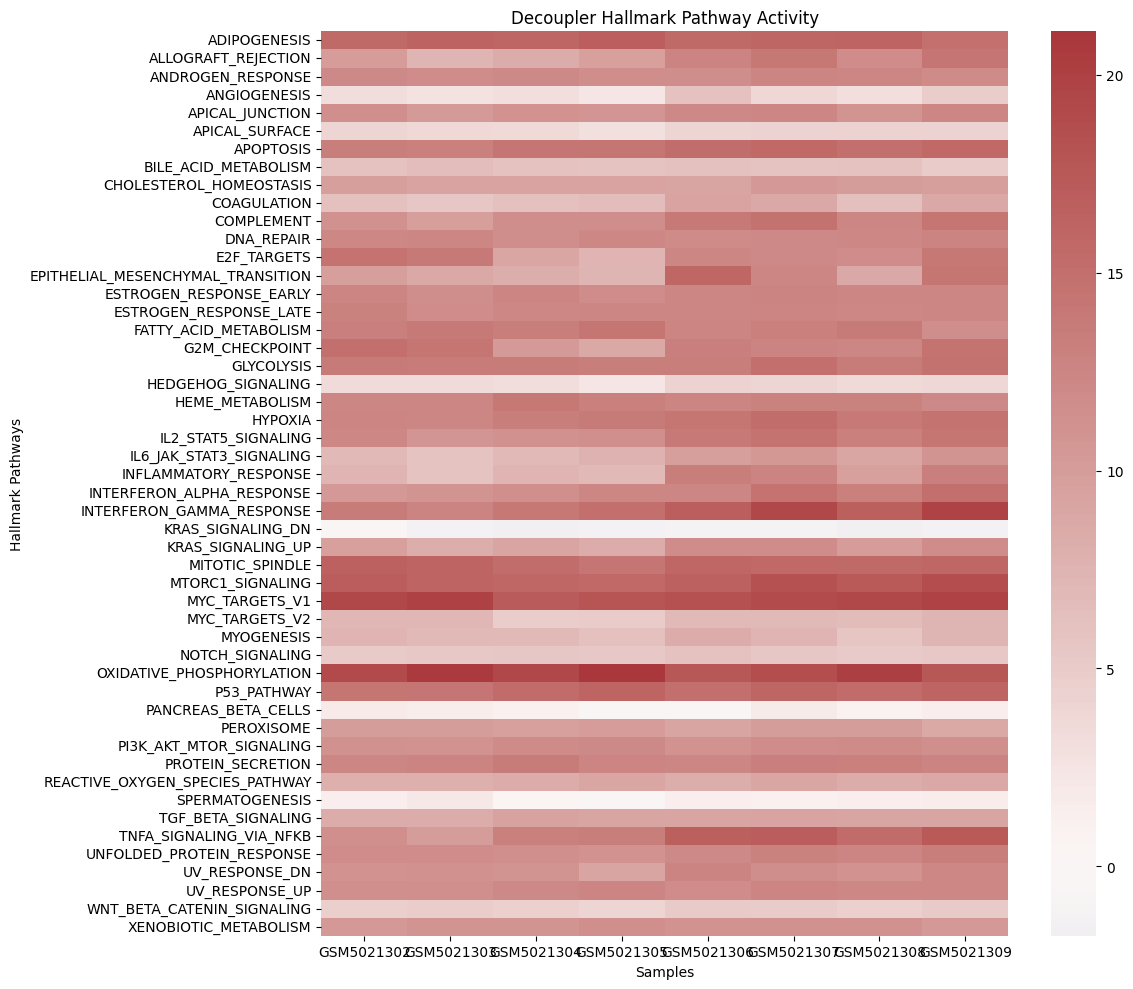

Decoupler activity plot saved!


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transpose: pathways as rows, samples as columns
activity_plot = activity.T

plt.figure(figsize=(12, 10))

sns.heatmap(
    activity_plot,
    cmap="vlag",
    center=0,
    xticklabels=True,
    yticklabels=True
)

plt.title("Decoupler Hallmark Pathway Activity")
plt.xlabel("Samples")
plt.ylabel("Hallmark Pathways")
plt.tight_layout()

plt.savefig("/content/decoupler_activity.png", dpi=300)
plt.show()

print("Decoupler activity plot saved!")

In [26]:
# Add sample condition information
activity_with_condition = activity.copy()

activity_with_condition["condition"] = metadata.set_index("sample")["condition"]

# Calculate mean activity for each condition
activity_summary = activity_with_condition.groupby("condition").mean().T

# Calculate Disease - Control activity difference
activity_summary["Disease_minus_Control"] = (
    activity_summary["Disease"] - activity_summary["Control"]
)

# Rank pathways by absolute difference
top_pathways = activity_summary.sort_values(
    "Disease_minus_Control",
    key=abs,
    ascending=False
)

print("Top pathways showing Disease vs Control differences:")
display(top_pathways.head(15))

Top pathways showing Disease vs Control differences:


condition,Control,Disease,Disease_minus_Control
INFLAMMATORY_RESPONSE,6.993872,12.278073,5.284202
TNFA_SIGNALING_VIA_NFKB,11.934431,16.648553,4.714122
ALLOGRAFT_REJECTION,8.852768,13.249145,4.396377
EPITHELIAL_MESENCHYMAL_TRANSITION,8.510561,12.905774,4.395213
INTERFERON_GAMMA_RESPONSE,13.871615,18.203271,4.331656
IL6_JAK_STAT3_SIGNALING,6.839090,10.069081,3.229991
COMPLEMENT,11.072331,13.879130,2.806799
KRAS_SIGNALING_UP,8.796465,11.393486,2.597020
IL2_STAT5_SIGNALING,11.432586,13.938940,2.506354
INTERFERON_ALPHA_RESPONSE,11.296906,13.747218,2.450312


In [27]:
import glob
import pandas as pd

# Find the DESeq2 result file
files_found = glob.glob("/content/differential_expression*.csv")

print("Files found:", files_found)

# Load the first matching file
de_results = pd.read_csv(files_found[0])

print("DE results shape:", de_results.shape)
print("Columns:")
print(de_results.columns.tolist())

display(de_results.head())

Files found: ['/content/differential_expression (1).csv', '/content/differential_expression.csv']
DE results shape: (24696, 8)
Columns:
['baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj', 'GeneID', 'neg_log10_padj']


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneID,neg_log10_padj
0,4.180990,-1.631507,1.194115,-1.366290,0.171848,0.476997,100287102,0.321485
1,652.849566,-0.813571,0.477211,-1.704846,0.088223,0.335073,653635,0.474861
2,30.682377,-0.502707,0.385429,-1.304277,0.192139,0.504454,102466751,0.297179
3,12.015084,-0.473311,0.597285,-0.792437,0.428106,0.732049,100996442,0.135460
4,198.461968,0.424296,0.737553,0.575276,0.565105,0.820957,729737,0.085680


In [30]:
# Filter significant genessignificant = de_results[    (de_results["padj"] < 0.05) &    (de_results["log2FoldChange"].abs() > 1)].copy()# Add directionsignificant["Direction"] = np.where(    significant["log2FoldChange"] > 0,    "Higher in Disease",    "Higher in Control")# Rank by effect size + statistical significancesignificant["biomarker_score"] = (    significant["log2FoldChange"].abs() *    -np.log10(significant["padj"]))candidate_biomarkers = significant.sort_values(    "biomarker_score",    ascending=False).head(20)print("Candidate biomarkers:", len(candidate_biomarkers))display(candidate_biomarkers[    ["GeneID", "log2FoldChange", "padj", "Direction", "biomarker_score"]])

In [31]:
# Add gene symbols
candidate_biomarkers["GeneSymbol"] = (
    candidate_biomarkers["GeneID"]
    .astype(str)
    .map(gene_map)
)

# Reorder columns
candidate_biomarkers = candidate_biomarkers[
    ["GeneSymbol", "GeneID", "log2FoldChange", "padj",
     "Direction", "biomarker_score"]
]

# Save
candidate_biomarkers.to_csv(
    "/content/candidate_biomarkers.csv",
    index=False
)

print("Candidate biomarker table saved!")
display(candidate_biomarkers)

NameError: name 'candidate_biomarkers' is not defined

In [33]:
import pandas as pd
import numpy as np

# Load DESeq2 results again
de_results = pd.read_csv("/content/differential_expression.csv")

# Select significant genes
significant = de_results[
    (de_results["padj"] < 0.05) &
    (de_results["log2FoldChange"].abs() > 1)
].copy()

# Direction
significant["Direction"] = np.where(
    significant["log2FoldChange"] > 0,
    "Higher in Disease",
    "Higher in Control"
)

# Biomarker score
significant["biomarker_score"] = (
    significant["log2FoldChange"].abs()
    * -np.log10(significant["padj"])
)

# Top 20 candidates
candidate_biomarkers = significant.sort_values(
    "biomarker_score",
    ascending=False
).head(20).copy()

print("Significant genes:", len(significant))
print("Candidate biomarkers:", len(candidate_biomarkers))

display(
    candidate_biomarkers[
        ["GeneID", "log2FoldChange", "padj",
         "Direction", "biomarker_score"]
    ]
)

Significant genes: 1672
Candidate biomarkers: 20


,GeneID,log2FoldChange,padj,Direction,biomarker_score
13280,6289,8.319965,1.380834e-12,Higher in Disease,98.673612
3085,5068,9.138323,1.976549e-09,Higher in Disease,79.540812
5997,3627,4.973547,1.216403e-15,Higher in Disease,74.180074
5971,6374,10.654830,3.324036e-07,Higher in Disease,69.025553
3408,3552,6.033067,1.944898e-11,Higher in Disease,64.620801
20151,9021,4.947884,1.822702e-11,Higher in Disease,53.136732
19416,6351,4.029141,5.417263e-13,Higher in Disease,49.422326
13278,100528017,6.465472,5.036692e-08,Higher in Disease,47.184077
7611,94234,5.742628,1.389311e-08,Higher in Disease,45.120983
21286,105372337,-7.994369,3.567784e-06,Higher in Control,43.550134


In [34]:
# Add gene symbols
candidate_biomarkers["GeneSymbol"] = (
    candidate_biomarkers["GeneID"]
    .astype(str)
    .map(gene_map)
)

# Arrange columns
candidate_biomarkers = candidate_biomarkers[
    ["GeneSymbol", "GeneID", "log2FoldChange",
     "padj", "Direction", "biomarker_score"]
]

# Save
candidate_biomarkers.to_csv(
    "/content/candidate_biomarkers.csv",
    index=False
)

print("Saved successfully!")
display(candidate_biomarkers)

Saved successfully!


,GeneSymbol,GeneID,log2FoldChange,padj,Direction,biomarker_score
13280,SAA2,6289,8.319965,1.380834e-12,Higher in Disease,98.673612
3085,REG3A,5068,9.138323,1.976549e-09,Higher in Disease,79.540812
5997,CXCL10,3627,4.973547,1.216403e-15,Higher in Disease,74.180074
5971,CXCL5,6374,10.654830,3.324036e-07,Higher in Disease,69.025553
3408,IL1A,3552,6.033067,1.944898e-11,Higher in Disease,64.620801
20151,SOCS3,9021,4.947884,1.822702e-11,Higher in Disease,53.136732
19416,CCL4,6351,4.029141,5.417263e-13,Higher in Disease,49.422326
13278,SAA2-SAA4,100528017,6.465472,5.036692e-08,Higher in Disease,47.184077
7611,FOXQ1,94234,5.742628,1.389311e-08,Higher in Disease,45.120983
21286,LOC105372337,105372337,-7.994369,3.567784e-06,Higher in Control,43.550134


In [35]:
# Save candidate biomarker table
candidate_biomarkers.to_csv(
    "/content/candidate_biomarkers.csv",
    index=False
)

print("Candidate biomarker table saved successfully!")

Candidate biomarker table saved successfully!


In [36]:
# Show the top 10 pathways increased in Diseasetop_increased = top_pathways[    top_pathways["Disease_minus_Control"] > 0].head(10)# Show the top 10 pathways decreased in Diseasetop_decreased = top_pathways[    top_pathways["Disease_minus_Control"] < 0].head(10)print("Pathways increased in Disease:")display(top_increased)print("Pathways decreased in Disease:")display(top_decreased)

In [37]:
print("Top 10 pathways:")
display(
    top_pathways[
        ["Disease", "Control", "Disease_minus_Control"]
    ].head(10)
)

Top 10 pathways:


condition,Disease,Control,Disease_minus_Control
INFLAMMATORY_RESPONSE,12.278073,6.993872,5.284202
TNFA_SIGNALING_VIA_NFKB,16.648553,11.934431,4.714122
ALLOGRAFT_REJECTION,13.249145,8.852768,4.396377
EPITHELIAL_MESENCHYMAL_TRANSITION,12.905774,8.510561,4.395213
INTERFERON_GAMMA_RESPONSE,18.203271,13.871615,4.331656
IL6_JAK_STAT3_SIGNALING,10.069081,6.839090,3.229991
COMPLEMENT,13.879130,11.072331,2.806799
KRAS_SIGNALING_UP,11.393486,8.796465,2.597020
IL2_STAT5_SIGNALING,13.938940,11.432586,2.506354
INTERFERON_ALPHA_RESPONSE,13.747218,11.296906,2.450312


In [38]:
# Save pathway activity results
top_pathways.to_csv(
    "/content/pathway_activity_results.csv"
)

print("Pathway activity results saved successfully!")

Pathway activity results saved successfully!


In [39]:
# Select the top 10 candidate biomarkers
top_biomarkers = candidate_biomarkers.head(10).copy()

print("Top 10 candidate biomarkers:")
display(
    top_biomarkers[
        ["GeneSymbol", "GeneID", "log2FoldChange",
         "padj", "Direction", "biomarker_score"]
    ]
)

Top 10 candidate biomarkers:


,GeneSymbol,GeneID,log2FoldChange,padj,Direction,biomarker_score
13280,SAA2,6289,8.319965,1.380834e-12,Higher in Disease,98.673612
3085,REG3A,5068,9.138323,1.976549e-09,Higher in Disease,79.540812
5997,CXCL10,3627,4.973547,1.216403e-15,Higher in Disease,74.180074
5971,CXCL5,6374,10.654830,3.324036e-07,Higher in Disease,69.025553
3408,IL1A,3552,6.033067,1.944898e-11,Higher in Disease,64.620801
20151,SOCS3,9021,4.947884,1.822702e-11,Higher in Disease,53.136732
19416,CCL4,6351,4.029141,5.417263e-13,Higher in Disease,49.422326
13278,SAA2-SAA4,100528017,6.465472,5.036692e-08,Higher in Disease,47.184077
7611,FOXQ1,94234,5.742628,1.389311e-08,Higher in Disease,45.120983
21286,LOC105372337,105372337,-7.994369,3.567784e-06,Higher in Control,43.550134


In [40]:
literature_summary = pd.DataFrame({
    "Gene": [
        "SAA2", "REG3A", "CXCL10", "CXCL5",
        "IL1A", "SOCS3", "CCL4", "FOXQ1"
    ],
    "Finding": [
        "Strongly increased in disease",
        "Strongly increased; reported in IBD literature",
        "Increased; associated with inflammatory/IFN signaling",
        "Strongly increased; associated with inflammatory responses",
        "Increased; inflammatory cytokine",
        "Increased; inflammation-related signaling regulator",
        "Increased; chemokine associated with immune recruitment",
        "Increased; epithelial-associated candidate"
    ],
    "Evidence_type": [
        "This study",
        "This study + literature support",
        "This study + literature support",
        "This study + literature support",
        "This study",
        "This study",
        "This study",
        "This study"
    ]
})

literature_summary.to_csv(
    "/content/literature_summary.csv",
    index=False
)

display(literature_summary)
print("Literature summary saved!")

,Gene,Finding,Evidence_type
0,SAA2,Strongly increased in disease,This study
1,REG3A,Strongly increased; reported in IBD literature,This study + literature support
2,CXCL10,Increased; associated with inflammatory/IFN si...,This study + literature support
3,CXCL5,Strongly increased; associated with inflammato...,This study + literature support
4,IL1A,Increased; inflammatory cytokine,This study
5,SOCS3,Increased; inflammation-related signaling regu...,This study
6,CCL4,Increased; chemokine associated with immune re...,This study
7,FOXQ1,Increased; epithelial-associated candidate,This study


Literature summary saved!


In [41]:
from google.colab import files

files.download("/content/decoupler_activity.png")
files.download("/content/candidate_biomarkers.csv")
files.download("/content/pathway_activity_results.csv")
files.download("/content/literature_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>